# Pertemuan 11 -  Unsupervised Learning: Clustering
Nama : Abdul Zaki Al-Muttaqin
Nim : 240401010042
Kelas : IF403

## Tujuan Praktikum
Mempelajari konsep Unsupervised Learning menggunakan algoritma K-Means untuk melakukan segmentasi pelanggan,menentukan jumlah cluster optimal dengan Metode Elbow, mengevaluasi hasil meggunakan Silhouette Score, serta membandingkan hasilnya dengan Hierarchical Clustering.

In [ ]:
# Generate dan Eksplorasi Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate dataset sintetis pelanggan
np.random.seed(42)

grp1 = np.random.normal([30, 20], [6, 8], (100, 2))   # Hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2))  # Menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2)) # Premium

data = np.vstack([grp1, grp2, grp3])

df = pd.DataFrame(
    data,
    columns=["pendapatan_tahunan", "skor_belanja"]
)

df["usia"] = np.random.randint(18, 65, len(df))
df["gender"] = np.random.choice(["L", "P"], len(df))

print("Shape:", df.shape)
print(df.describe().round(2))

df.head()

Shape: (300, 4)
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


,pendapatan_tahunan,skor_belanja,usia,gender
0,32.980285,18.893886,64,P
1,33.886131,32.184239,21,P
2,28.595080,18.126904,29,L
3,39.475277,26.139478,62,L
4,27.183154,24.340480,19,L


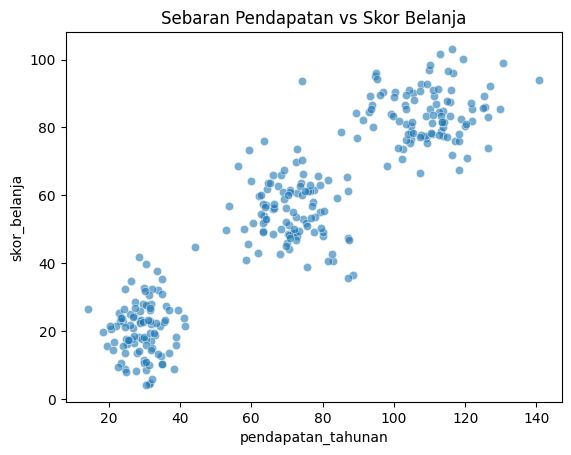

In [ ]:
# Visualisasi Awal
sns.scatterplot(
    data=df,
    x="pendapatan_tahunan",
    y="skor_belanja",
    alpha=0.6
)

plt.title("Sebaran Pendapatan vs Skor Belanja")
plt.show()

In [ ]:
# StandarScaler
from sklearn.preprocessing import StandardScaler

# Mengambil dua fitur utama
X = df[["pendapatan_tahunan", "skor_belanja"]]

# Standardisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape:", X_scaled.shape)

print("\n5 Data Pertama Setelah Scaling:")
print(pd.DataFrame(
    X_scaled,
    columns=["pendapatan_tahunan", "skor_belanja"]
).head())

Shape: (300, 2)

5 Data Pertama Setelah Scaling:
   pendapatan_tahunan  skor_belanja
0           -1.095301     -1.254965
1           -1.068471     -0.769243
2           -1.225183     -1.282996
3           -0.902930     -0.990161
4           -1.267002     -1.055909


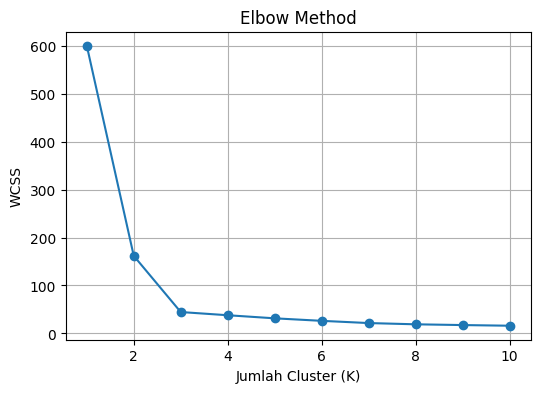

In [ ]:
# Elbow Method
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [ ]:
# Membangun model K-Means
from sklearn.cluster import KMeans

# Membuat model K-Means dengan 3 cluster
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Melatih model
clusters = kmeans.fit_predict(X_scaled)

# Menambahkan hasil cluster ke dataframe
df["Cluster"] = clusters

print(df.head())

   pendapatan_tahunan  skor_belanja  usia gender  Cluster
0           32.980285     18.893886    64      P        1
1           33.886131     32.184239    21      P        1
2           28.595080     18.126904    29      L        1
3           39.475277     26.139478    62      L        1
4           27.183154     24.340480    19      L        1


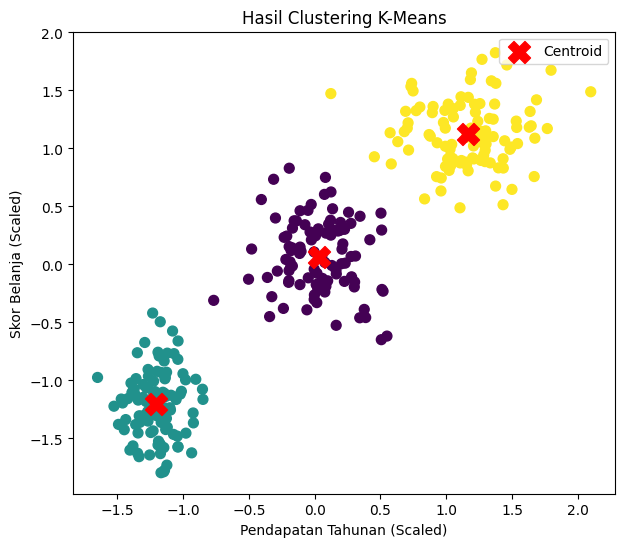

In [ ]:
# Visualisasi Hasil Clustering
plt.figure(figsize=(7,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters,
    cmap="viridis",
    s=50
)

# Menampilkan centroid
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    c="red",
    marker="X",
    s=250,
    label="Centroid"
)

plt.title("Hasil Clustering K-Means")
plt.xlabel("Pendapatan Tahunan (Scaled)")
plt.ylabel("Skor Belanja (Scaled)")
plt.legend()

plt.show()

In [ ]:
# Menghitung Silhouette Score
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", round(score,3))

Silhouette Score: 0.695


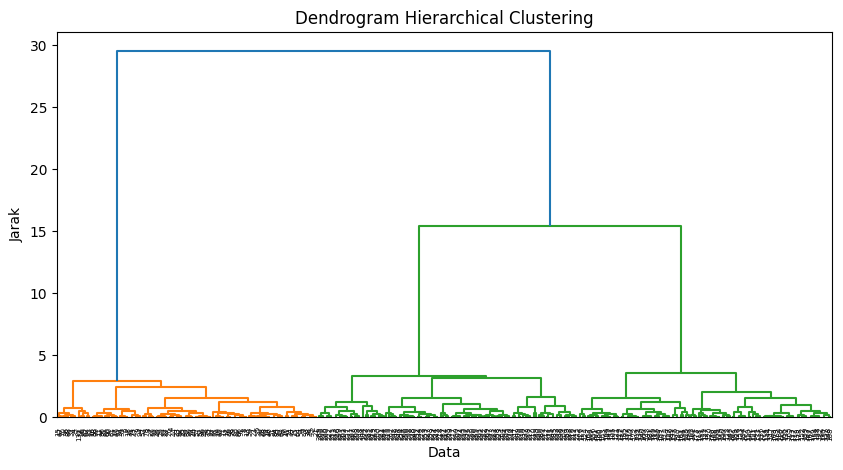

In [ ]:
# Hierarchical Clustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Membuat linkage
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))

dendrogram(linked)

plt.title("Dendrogram Hierarchical Clustering")
plt.xlabel("Data")
plt.ylabel("Jarak")

plt.show()


In [ ]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3)

hc_cluster = hc.fit_predict(X_scaled)

df["HC_Cluster"] = hc_cluster

print(df.head())


   pendapatan_tahunan  skor_belanja  usia gender  Cluster  HC_Cluster
0           32.980285     18.893886    64      P        1           1
1           33.886131     32.184239    21      P        1           1
2           28.595080     18.126904    29      L        1           1
3           39.475277     26.139478    62      L        1           1
4           27.183154     24.340480    19      L        1           1


# Kesimpulan

Pada praktikum ini saya mempelajari konsep Unsupervised Learning menggunakan algoritma K-Means untuk mengelompokkan data pelanggan berdasarkan pendapatan tahunan dan skor belanja. Sebelum proses clustering dilakukan, data dinormalisasi menggunakan StandardScaler agar setiap fitur memiliki skala yang seimbang.

Jumlah cluster ditentukan menggunakan Elbow Method dan diperoleh nilai K = 3 sebagai jumlah cluster yang paling optimal. Hasil clustering menunjukkan tiga kelompok pelanggan yang berbeda dengan centroid berada di pusat masing-masing kelompok. Nilai Silhouette Score sebesar 0,695 menunjukkan bahwa hasil pengelompokan sudah cukup baik karena setiap cluster memiliki pemisahan yang jelas.

Selain itu, saya juga mempelajari Hierarchical Clustering melalui dendrogram sebagai metode lain untuk melihat hubungan antar data. Dari praktikum ini saya memahami bahwa algoritma clustering dapat digunakan untuk melakukan segmentasi data tanpa memerlukan label atau target sehingga sangat bermanfaat dalam analisis pelanggan maupun pengelompokan data lainnya.

Sebagai keterbatasan, data yang digunakan merupakan data sintetis sehingga hasil clustering belum tentu sama jika diterapkan pada data pelanggan nyata. Selain itu, pemilihan jumlah cluster dapat berbeda jika menggunakan dataset atau metode evaluasi yang berbeda.